In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print("All libraries loaded successfully!")

All libraries loaded successfully!


In [2]:
path = "C:/Users/prava/Downloads/ecommerce sales/"

orders    = pd.read_csv(path + "olist_orders_dataset.csv")
customers = pd.read_csv(path + "olist_customers_dataset.csv")
items     = pd.read_csv(path + "olist_order_items_dataset.csv")
payments  = pd.read_csv(path + "olist_order_payments_dataset.csv")
reviews   = pd.read_csv(path + "olist_order_reviews_dataset.csv")
products  = pd.read_csv(path + "olist_products_dataset.csv")
sellers   = pd.read_csv(path + "olist_sellers_dataset.csv")
geo       = pd.read_csv(path + "olist_geolocation_dataset.csv")

print("orders   :", orders.shape)
print("customers:", customers.shape)
print("items    :", items.shape)
print("payments :", payments.shape)
print("reviews  :", reviews.shape)
print("products :", products.shape)
print("sellers  :", sellers.shape)
print("geo      :", geo.shape)

orders   : (99441, 8)
customers: (99441, 5)
items    : (112650, 7)
payments : (103886, 5)
reviews  : (99224, 7)
products : (32951, 9)
sellers  : (3095, 4)
geo      : (1000163, 5)


In [3]:
orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [4]:
print("=== ORDERS columns ===")
print(orders.columns.tolist())

print("\n=== CUSTOMERS columns ===")
print(customers.columns.tolist())

print("\n=== ITEMS columns ===")
print(items.columns.tolist())

print("\n=== PAYMENTS columns ===")
print(payments.columns.tolist())

print("\n=== REVIEWS columns ===")
print(reviews.columns.tolist())

print("\n=== PRODUCTS columns ===")
print(products.columns.tolist())

print("\n=== SELLERS columns ===")
print(sellers.columns.tolist())

print("\n=== GEO columns ===")
print(geo.columns.tolist())

=== ORDERS columns ===
['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date']

=== CUSTOMERS columns ===
['customer_id', 'customer_unique_id', 'customer_zip_code_prefix', 'customer_city', 'customer_state']

=== ITEMS columns ===
['order_id', 'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date', 'price', 'freight_value']

=== PAYMENTS columns ===
['order_id', 'payment_sequential', 'payment_type', 'payment_installments', 'payment_value']

=== REVIEWS columns ===
['review_id', 'order_id', 'review_score', 'review_comment_title', 'review_comment_message', 'review_creation_date', 'review_answer_timestamp']

=== PRODUCTS columns ===
['product_id', 'product_category_name', 'product_name_lenght', 'product_description_lenght', 'product_photos_qty', 'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm']

=== SELLERS columns

In [5]:
print("=== DAY 3 SUMMARY ===")
print(f"Total orders loaded    : {len(orders)}")
print(f"Total customers        : {len(customers)}")
print(f"Total order items      : {len(items)}")
print(f"Total payment records  : {len(payments)}")
print(f"Total reviews          : {len(reviews)}")
print(f"Total products         : {len(products)}")
print(f"Total sellers          : {len(sellers)}")
print("Status: All 8 tables loaded successfully!")

=== DAY 3 SUMMARY ===
Total orders loaded    : 99441
Total customers        : 99441
Total order items      : 112650
Total payment records  : 103886
Total reviews          : 99224
Total products         : 32951
Total sellers          : 3095
Status: All 8 tables loaded successfully!


In [6]:


print("=== MISSING VALUES IN EACH TABLE ===\n")

tables = {
    'orders'   : orders,
    'customers': customers,
    'items'    : items,
    'payments' : payments,
    'reviews'  : reviews,
    'products' : products,
    'sellers'  : sellers,
    'geo'      : geo
}

for name, df in tables.items():
    missing = df.isnull().sum().sum()
    pct = round((missing / (df.shape[0] * df.shape[1])) * 100, 2)
    print(f"{name:12} | rows: {df.shape[0]:7} | cols: {df.shape[1]} | missing cells: {missing:6} | {pct}% missing")

=== MISSING VALUES IN EACH TABLE ===

orders       | rows:   99441 | cols: 8 | missing cells:   4908 | 0.62% missing
customers    | rows:   99441 | cols: 5 | missing cells:      0 | 0.0% missing
items        | rows:  112650 | cols: 7 | missing cells:      0 | 0.0% missing
payments     | rows:  103886 | cols: 5 | missing cells:      0 | 0.0% missing
reviews      | rows:   99224 | cols: 7 | missing cells: 145903 | 21.01% missing
products     | rows:   32951 | cols: 9 | missing cells:   2448 | 0.83% missing
sellers      | rows:    3095 | cols: 4 | missing cells:      0 | 0.0% missing
geo          | rows: 1000163 | cols: 5 | missing cells:      0 | 0.0% missing


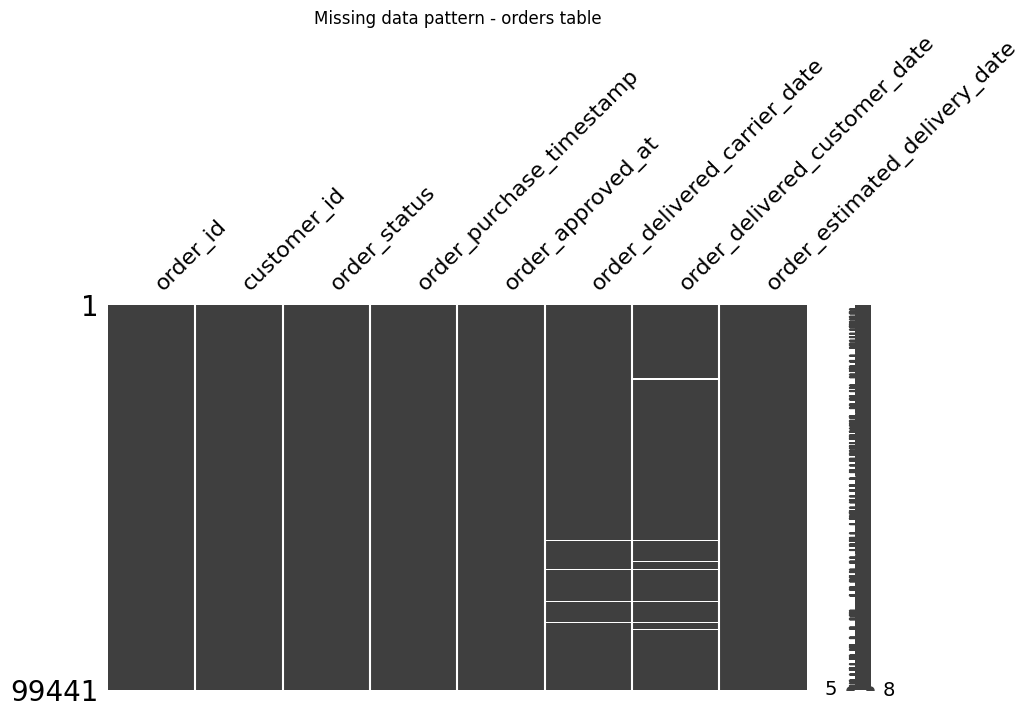

In [7]:
import missingno as msno
import matplotlib.pyplot as plt

msno.matrix(orders, figsize=(10, 5))
plt.title("Missing data pattern - orders table")
plt.tight_layout()
plt.savefig("missing_orders.png")
plt.show()

In [8]:
import pandas as pd

path = "C:/Users/prava/Downloads/ecommerce sales/"

# Load all datasets
orders      = pd.read_csv(path + "olist_orders_dataset.csv")
payments    = pd.read_csv(path + "olist_order_payments_dataset.csv")
reviews     = pd.read_csv(path + "olist_order_reviews_dataset.csv")
products    = pd.read_csv(path + "olist_products_dataset.csv")
customers   = pd.read_csv(path + "olist_customers_dataset.csv")
sellers     = pd.read_csv(path + "olist_sellers_dataset.csv")
translation = pd.read_csv(path + "product_category_name_translation.csv")

# Convert datetime columns
date_cols = ['order_purchase_timestamp', 'order_approved_at',
             'order_delivered_carrier_date', 'order_delivered_customer_date',
             'order_estimated_delivery_date']
orders[date_cols] = orders[date_cols].apply(pd.to_datetime)

# Fix missing values
orders['order_approved_at'].fillna(orders['order_purchase_timestamp'], inplace=True)

print("All datasets loaded successfully!")

All datasets loaded successfully!


In [9]:
# Delivery time in days
orders['delivery_days'] = (
    orders['order_delivered_customer_date'] - orders['order_purchase_timestamp']
).dt.days

# Was delivery early or late? (positive = late, negative = early)
orders['delivery_delay'] = (
    orders['order_delivered_customer_date'] - orders['order_estimated_delivery_date']
).dt.days

# Extract month and day of week for trend analysis
orders['order_month'] = orders['order_purchase_timestamp'].dt.to_period('M')
orders['order_dayofweek'] = orders['order_purchase_timestamp'].dt.day_name()

print(orders[['delivery_days','delivery_delay','order_month','order_dayofweek']].head())

   delivery_days  delivery_delay order_month order_dayofweek
0            8.0            -8.0     2017-10          Monday
1           13.0            -6.0     2018-07         Tuesday
2            9.0           -18.0     2018-08       Wednesday
3           13.0           -13.0     2017-11        Saturday
4            2.0           -10.0     2018-02         Tuesday


In [10]:
# Translate product categories to English
products = products.merge(translation, on='product_category_name', how='left')

# Summarise payments per order (one row per order)
pay_agg = payments.groupby('order_id').agg(
    total_payment=('payment_value', 'sum'),
    payment_type=('payment_type', 'first'),
    installments=('payment_installments', 'max')
).reset_index()

# Summarise reviews per order
rev_agg = reviews.groupby('order_id').agg(
    review_score=('review_score', 'mean')
).reset_index()

# Build master dataframe step by step
df = orders.merge(customers, on='customer_id', how='left')
df = df.merge(pay_agg,       on='order_id',   how='left')
df = df.merge(rev_agg,       on='order_id',   how='left')

print("Master dataframe shape:", df.shape)
print(df.head())

Master dataframe shape: (99441, 20)
                           order_id                       customer_id  \
0  e481f51cbdc54678b7cc49136f2d6af7  9ef432eb6251297304e76186b10a928d   
1  53cdb2fc8bc7dce0b6741e2150273451  b0830fb4747a6c6d20dea0b8c802d7ef   
2  47770eb9100c2d0c44946d9cf07ec65d  41ce2a54c0b03bf3443c3d931a367089   
3  949d5b44dbf5de918fe9c16f97b45f8a  f88197465ea7920adcdbec7375364d82   
4  ad21c59c0840e6cb83a9ceb5573f8159  8ab97904e6daea8866dbdbc4fb7aad2c   

  order_status order_purchase_timestamp   order_approved_at  \
0    delivered      2017-10-02 10:56:33 2017-10-02 11:07:15   
1    delivered      2018-07-24 20:41:37 2018-07-26 03:24:27   
2    delivered      2018-08-08 08:38:49 2018-08-08 08:55:23   
3    delivered      2017-11-18 19:28:06 2017-11-18 19:45:59   
4    delivered      2018-02-13 21:18:39 2018-02-13 22:20:29   

  order_delivered_carrier_date order_delivered_customer_date  \
0          2017-10-04 19:55:00           2017-10-10 21:25:13   
1          2018-07

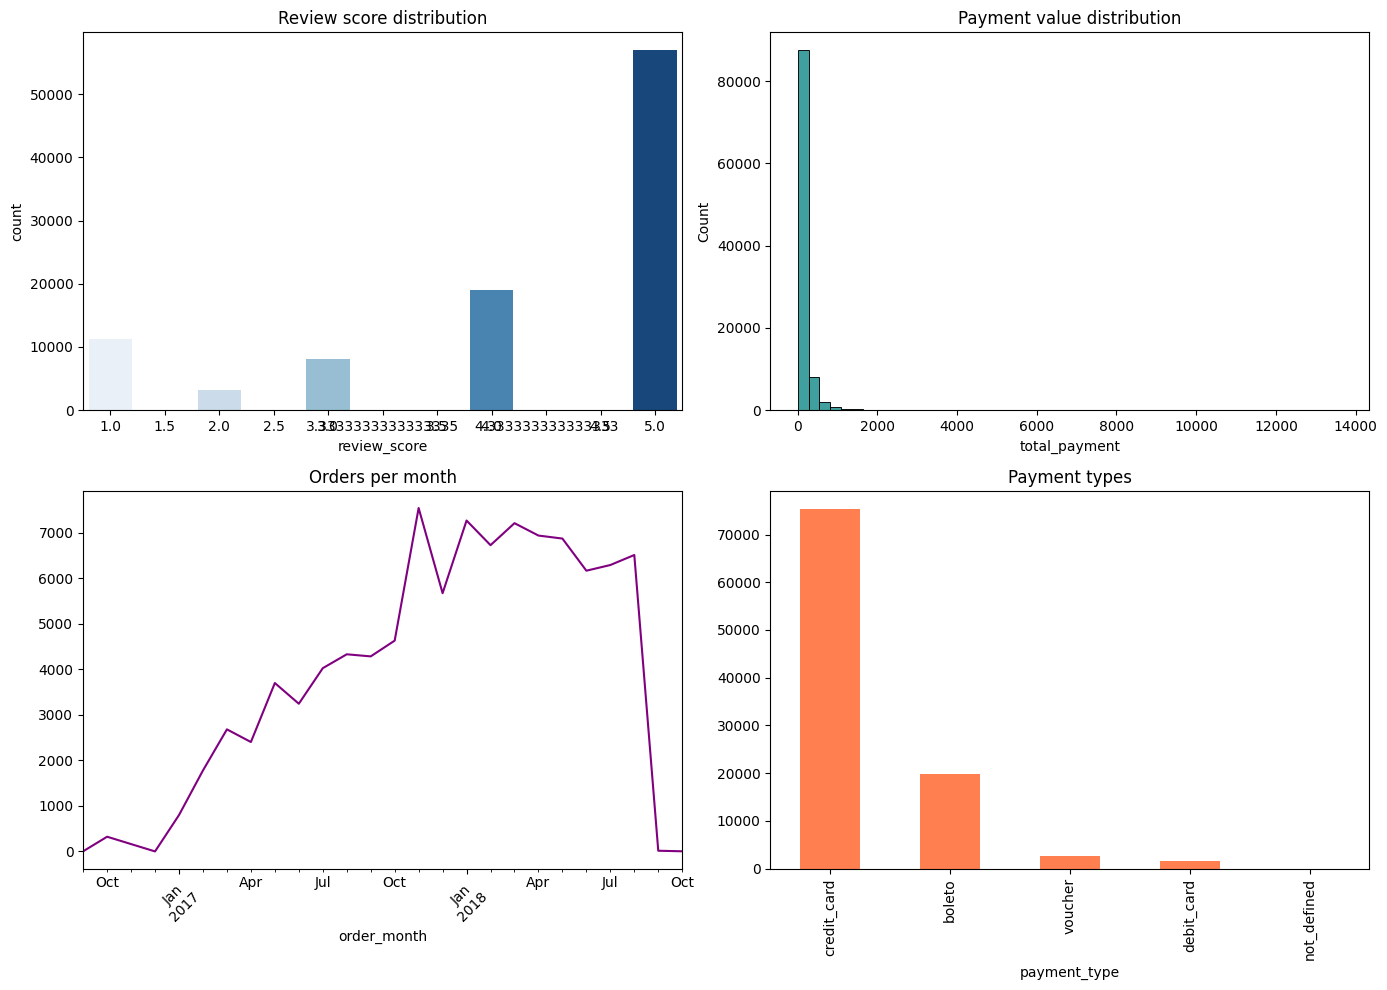

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Review score distribution
sns.countplot(x='review_score', data=df, ax=axes[0,0], palette='Blues')
axes[0,0].set_title('Review score distribution')

# 2. Payment value distribution
sns.histplot(df['total_payment'].dropna(), bins=50, ax=axes[0,1], color='teal')
axes[0,1].set_title('Payment value distribution')

# 3. Orders over time
df.groupby('order_month').size().plot(ax=axes[1,0], color='purple')
axes[1,0].set_title('Orders per month')
axes[1,0].tick_params(axis='x', rotation=45)

# 4. Payment type breakdown
df['payment_type'].value_counts().plot(kind='bar', ax=axes[1,1], color='coral')
axes[1,1].set_title('Payment types')

plt.tight_layout()
plt.savefig('univariate_analysis.png')
plt.show()

In [12]:
# Check what columns products and translation have
print("Products columns:", products.columns.tolist())
print("Translation columns:", translation.columns.tolist())
print()
print("Products sample:")
print(products['product_category_name'].head())
print()
print("Translation sample:")
print(translation.head())

Products columns: ['product_id', 'product_category_name', 'product_name_lenght', 'product_description_lenght', 'product_photos_qty', 'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm', 'product_category_name_english']
Translation columns: ['product_category_name', 'product_category_name_english']

Products sample:
0               perfumaria
1                    artes
2            esporte_lazer
3                    bebes
4    utilidades_domesticas
Name: product_category_name, dtype: object

Translation sample:
    product_category_name product_category_name_english
0            beleza_saude                 health_beauty
1  informatica_acessorios         computers_accessories
2              automotivo                          auto
3         cama_mesa_banho                bed_bath_table
4        moveis_decoracao               furniture_decor


In [13]:
# Step 1: Reload products and translation fresh
products    = pd.read_csv(path + "olist_products_dataset.csv")
translation = pd.read_csv(path + "product_category_name_translation.csv")

# Step 2: Check column names match exactly
print("Translation columns:", translation.columns.tolist())
# Should show: ['product_category_name', 'product_category_name_english']

# Step 3: Merge translation into products
products = products.merge(translation, on='product_category_name', how='left')
print("After merge:", products.columns.tolist())
print(products[['product_category_name','product_category_name_english']].head())

# Step 4: Load order_items
order_items = pd.read_csv(path + "olist_order_items_dataset.csv")
print("Order items columns:", order_items.columns.tolist())

# Step 5: Merge order_items with products
items_products = order_items.merge(
    products[['product_id', 'product_category_name_english']],
    on='product_id', how='left'
)

# Step 6: One row per order
items_agg = items_products.groupby('order_id').agg(
    product_category_name_english=('product_category_name_english', 'first')
).reset_index()

# Step 7: Add to master df
df = df.merge(items_agg, on='order_id', how='left')

# Confirm it worked
print("\n✓ Column added successfully!")
print(df['product_category_name_english'].value_counts().head(10))

Translation columns: ['product_category_name', 'product_category_name_english']
After merge: ['product_id', 'product_category_name', 'product_name_lenght', 'product_description_lenght', 'product_photos_qty', 'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm', 'product_category_name_english']
   product_category_name product_category_name_english
0             perfumaria                     perfumery
1                  artes                           art
2          esporte_lazer                sports_leisure
3                  bebes                          baby
4  utilidades_domesticas                    housewares
Order items columns: ['order_id', 'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date', 'price', 'freight_value']

✓ Column added successfully!
product_category_name_english
bed_bath_table           9315
health_beauty            8796
sports_leisure           7683
computers_accessories    6661
furniture_decor          6355
housewares

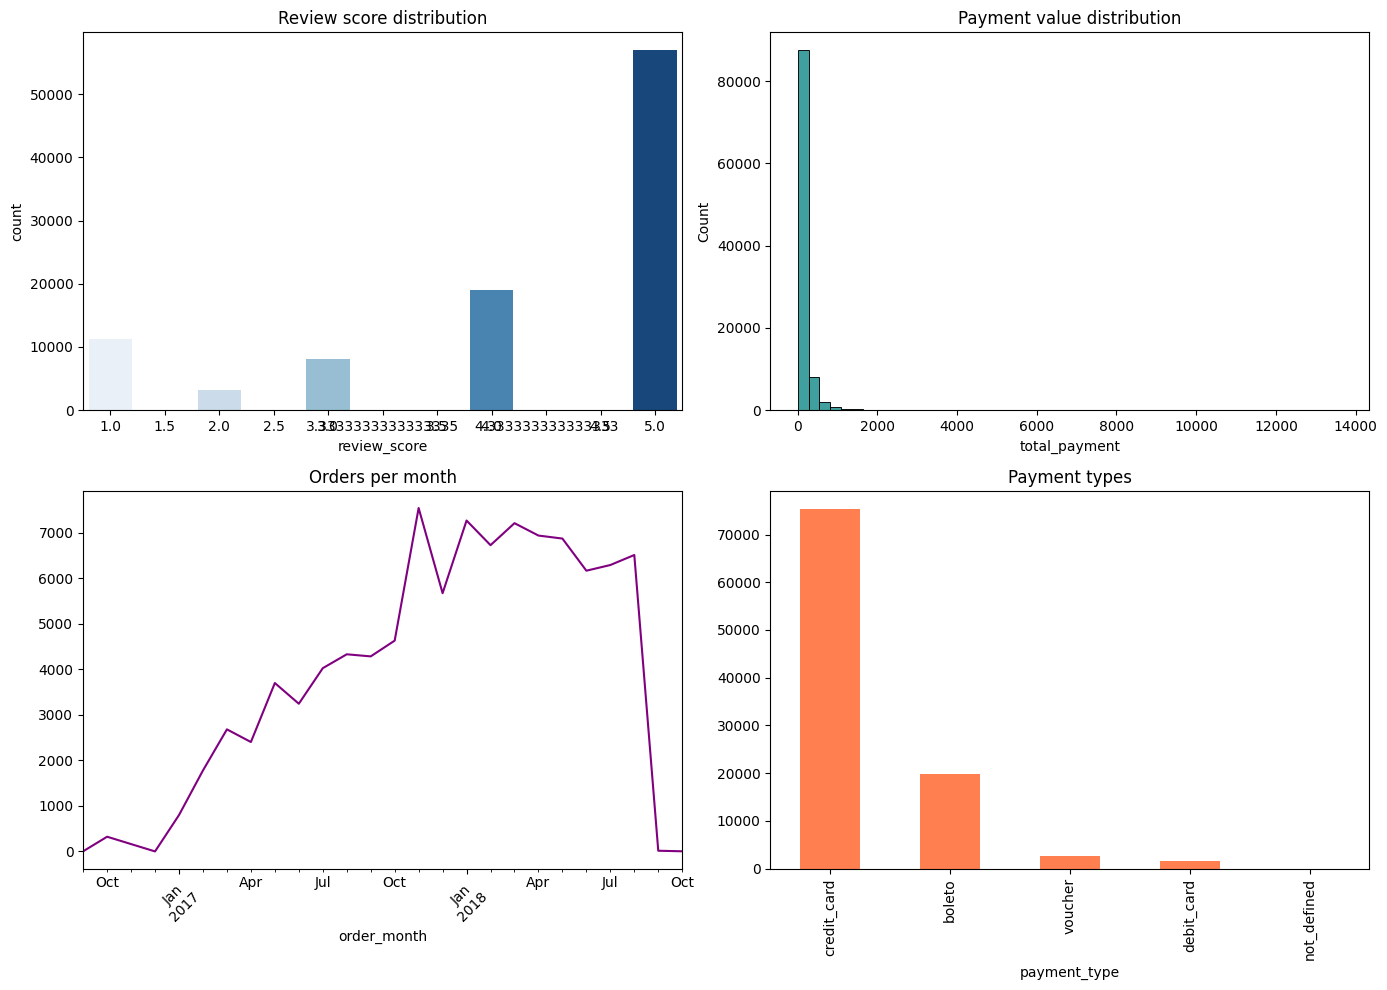

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Review score distribution
sns.countplot(x='review_score', data=df, ax=axes[0,0], palette='Blues')
axes[0,0].set_title('Review score distribution')

# 2. Payment value distribution
sns.histplot(df['total_payment'].dropna(), bins=50, ax=axes[0,1], color='teal')
axes[0,1].set_title('Payment value distribution')

# 3. Orders per month
df.groupby('order_month').size().plot(ax=axes[1,0], color='purple')
axes[1,0].set_title('Orders per month')
axes[1,0].tick_params(axis='x', rotation=45)

# 4. Payment type breakdown
df['payment_type'].value_counts().plot(kind='bar', ax=axes[1,1], color='coral')
axes[1,1].set_title('Payment types')

plt.tight_layout()
plt.savefig('univariate_analysis.png')
plt.show()

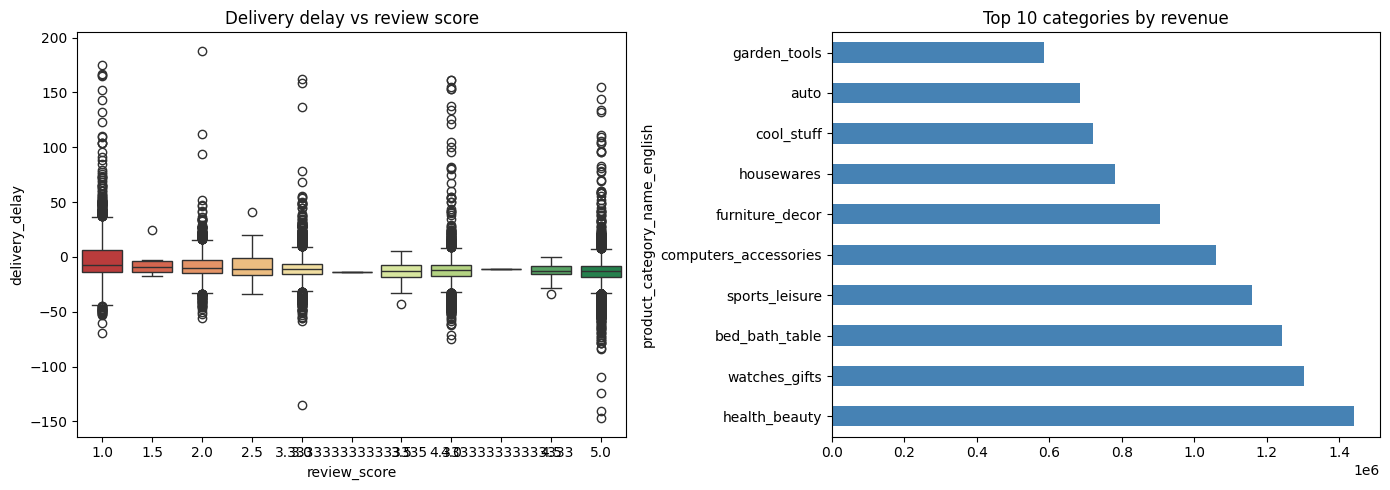

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Does late delivery = bad review?
sns.boxplot(x='review_score', y='delivery_delay',
            data=df, ax=axes[0], palette='RdYlGn')
axes[0].set_title('Delivery delay vs review score')

# Top categories by revenue
top_cats = (df.groupby('product_category_name_english')['total_payment']
              .sum().sort_values(ascending=False).head(10))
top_cats.plot(kind='barh', ax=axes[1], color='steelblue')
axes[1].set_title('Top 10 categories by revenue')

plt.tight_layout()
plt.savefig('bivariate_analysis.png')
plt.show()

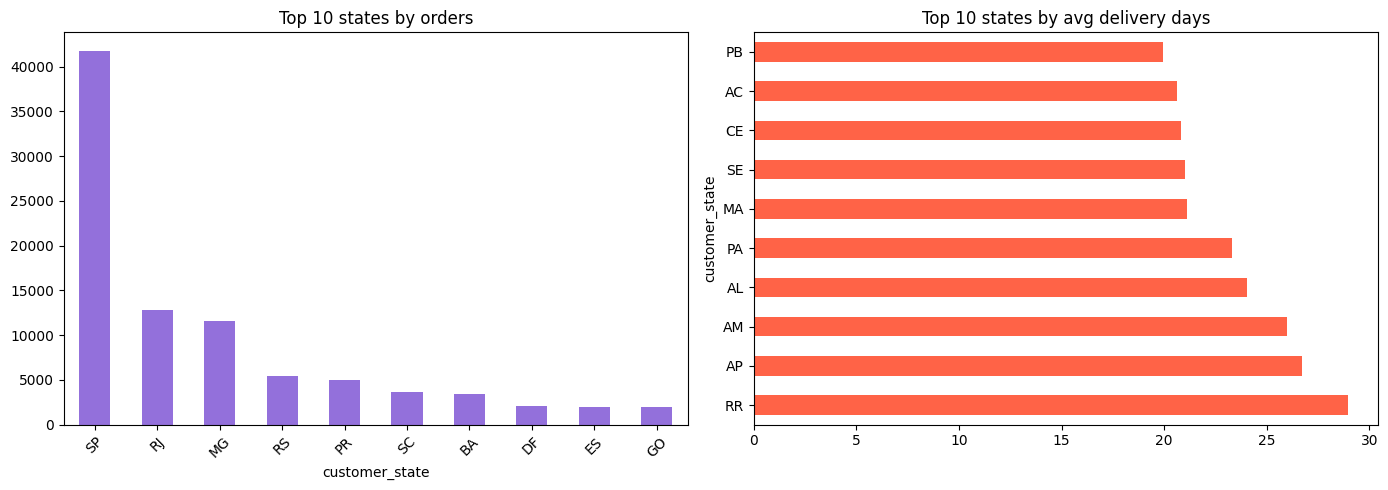

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Orders by state
state_orders = df['customer_state'].value_counts().head(10)
state_orders.plot(kind='bar', ax=axes[0], color='mediumpurple')
axes[0].set_title('Top 10 states by orders')
axes[0].tick_params(axis='x', rotation=45)

# Average delivery days by state
state_delivery = (df.groupby('customer_state')['delivery_days']
                    .mean().sort_values(ascending=False).head(10))
state_delivery.plot(kind='barh', ax=axes[1], color='tomato')
axes[1].set_title('Top 10 states by avg delivery days')

plt.tight_layout()
plt.savefig('geospatial_analysis.png')
plt.show()

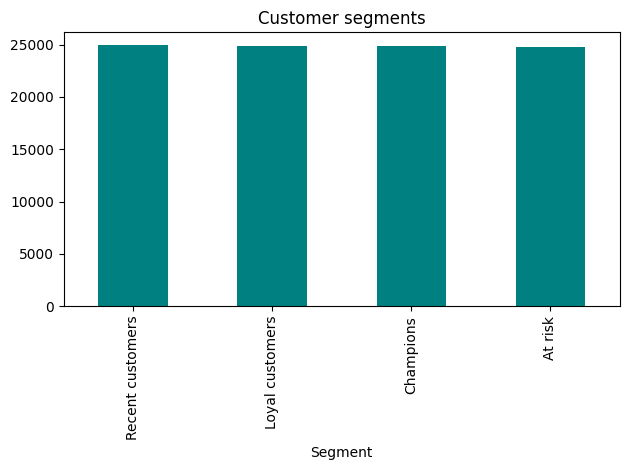

                        customer_id  Recency  Frequency  Monetary  \
0  00012a2ce6f8dcda20d059ce98491703      338          1    114.74   
1  000161a058600d5901f007fab4c27140      459          1     67.41   
2  0001fd6190edaaf884bcaf3d49edf079      597          1    195.42   
3  0002414f95344307404f0ace7a26f1d5      428          1    179.35   
4  000379cdec625522490c315e70c7a9fb      199          1    107.01   
5  0004164d20a9e969af783496f3408652      554          1     71.80   
6  000419c5494106c306a97b5635748086      229          1     49.40   
7  00046a560d407e99b969756e0b10f282      304          1    166.59   
8  00050bf6e01e69d5c0fd612f1bcfb69c      396          1     85.23   
9  000598caf2ef4117407665ac33275130       68          1   1255.71   

            Segment  
0           At risk  
1           At risk  
2           At risk  
3           At risk  
4  Recent customers  
5           At risk  
6  Recent customers  
7           At risk  
8           At risk  
9  Recent customers 

In [17]:
import datetime

snapshot_date = df['order_purchase_timestamp'].max() + datetime.timedelta(days=1)

rfm = df.groupby('customer_id').agg(
    Recency   = ('order_purchase_timestamp', lambda x: (snapshot_date - x.max()).days),
    Frequency = ('order_id', 'count'),
    Monetary  = ('total_payment', 'sum')
).reset_index()

# Score 1-4
rfm['R_score'] = pd.qcut(rfm['Recency'],
                          q=4, labels=[4,3,2,1])
rfm['F_score'] = pd.qcut(rfm['Frequency'].rank(method='first'),
                          q=4, labels=[1,2,3,4])
rfm['M_score'] = pd.qcut(rfm['Monetary'],
                          q=4, labels=[1,2,3,4])

rfm['RFM_score'] = (rfm['R_score'].astype(str) +
                    rfm['F_score'].astype(str) +
                    rfm['M_score'].astype(str))

# Segment labels
def segment(score):
    r = int(score[0])
    f = int(score[1])
    if r >= 3 and f >= 3: return 'Champions'
    elif r >= 3:           return 'Recent customers'
    elif f >= 3:           return 'Loyal customers'
    elif r <= 2 and f <= 2:return 'At risk'
    else:                  return 'Others'

rfm['Segment'] = rfm['RFM_score'].apply(segment)

# Plot segments
rfm['Segment'].value_counts().plot(kind='bar', color='teal')
plt.title('Customer segments')
plt.tight_layout()
plt.savefig('rfm_segments.png')
plt.show()

print(rfm[['customer_id','Recency','Frequency','Monetary','Segment']].head(10))

In [18]:
print("=" * 40)
print("      KEY BUSINESS INSIGHTS")
print("=" * 40)
print(f"Total orders        : {df.shape[0]:,}")
print(f"Avg review score    : {df['review_score'].mean():.2f} / 5")
print(f"Avg delivery days   : {df['delivery_days'].mean():.1f} days")
print(f"Avg order value     : R$ {df['total_payment'].mean():.2f}")
print(f"Late deliveries     : {(df['delivery_delay']>0).sum():,} "
      f"({(df['delivery_delay']>0).mean()*100:.1f}%)")
print(f"Top payment method  : {df['payment_type'].value_counts().index[0]}")
print(f"Top state by orders : {df['customer_state'].value_counts().index[0]}")
print(f"Top category        : {df['product_category_name_english'].value_counts().index[0]}")

      KEY BUSINESS INSIGHTS
Total orders        : 99,441
Avg review score    : 4.09 / 5
Avg delivery days   : 12.1 days
Avg order value     : R$ 160.99
Late deliveries     : 6,535 (6.6%)
Top payment method  : credit_card
Top state by orders : SP
Top category        : bed_bath_table


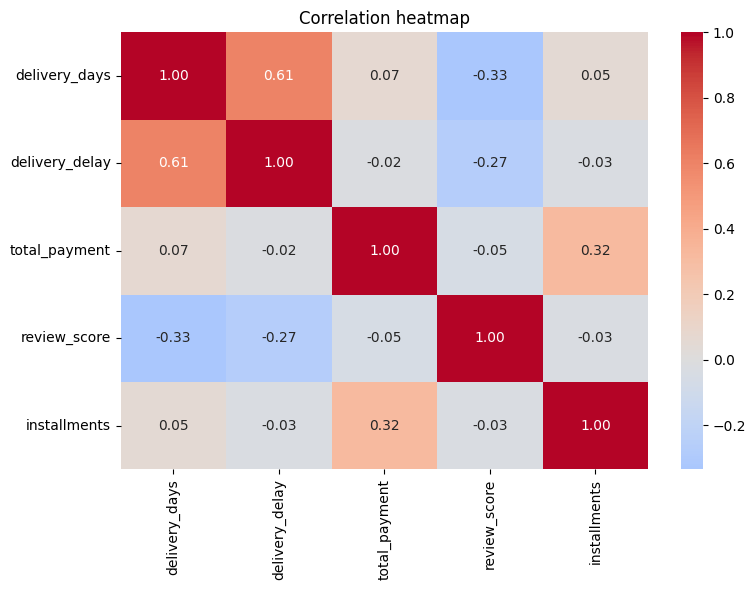

In [19]:
   # See how all numeric columns relate to each other  EXTENSION
numeric_cols = ['delivery_days', 'delivery_delay',
                'total_payment', 'review_score', 'installments']

plt.figure(figsize=(8, 6))
sns.heatmap(df[numeric_cols].corr(),
            annot=True, fmt='.2f',
            cmap='coolwarm', center=0)
plt.title('Correlation heatmap')
plt.tight_layout()
plt.savefig('correlation_heatmap.png')
plt.show()

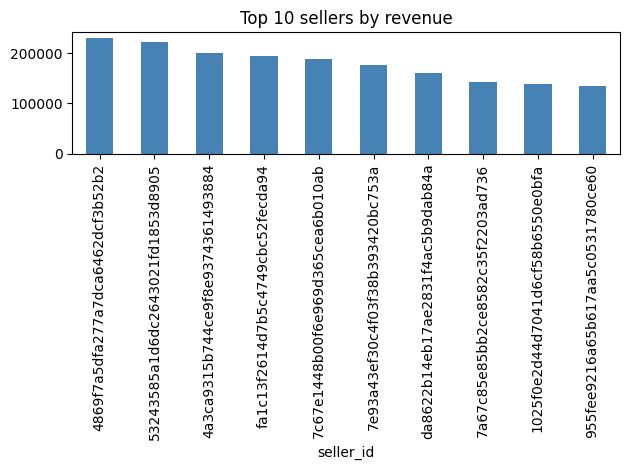

In [20]:
# Load order items if not already loaded
order_items = pd.read_csv(path + "olist_order_items_dataset.csv")

# Merge with reviews
seller_perf = order_items.merge(
    df[['order_id', 'review_score', 'delivery_days']],
    on='order_id', how='left'
)

# Top 10 sellers by revenue
top_sellers = (seller_perf.groupby('seller_id')['price']
                           .sum()
                           .sort_values(ascending=False)
                           .head(10))

top_sellers.plot(kind='bar', color='steelblue')
plt.title('Top 10 sellers by revenue')
plt.tight_layout()
plt.show()

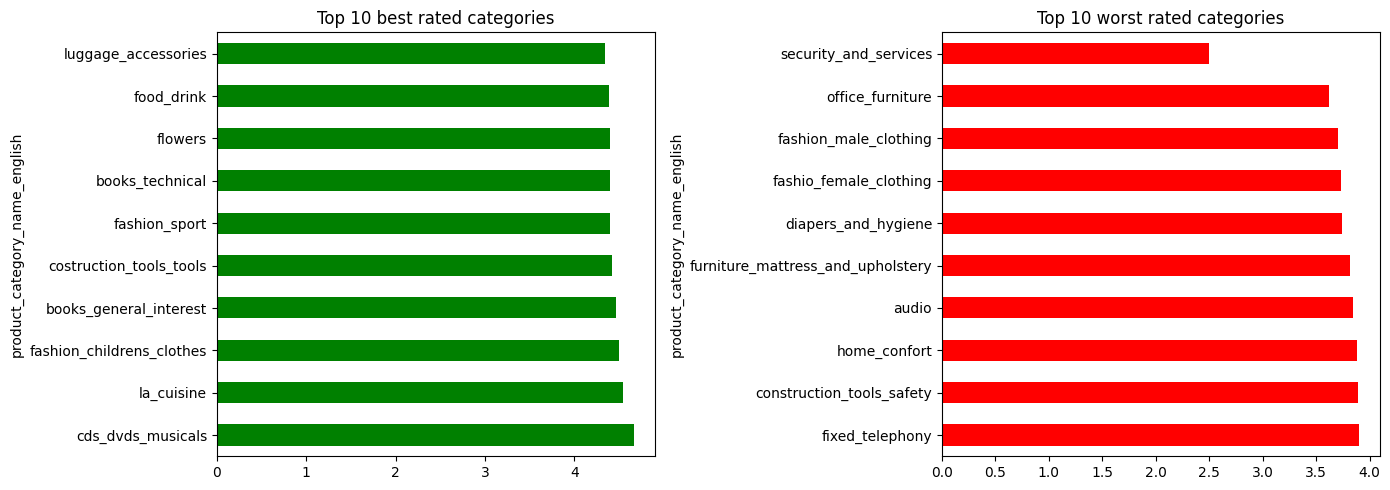

In [21]:
# Which category gets best / worst reviews?
cat_reviews = (df.groupby('product_category_name_english')['review_score']
                 .mean()
                 .sort_values(ascending=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Best rated
cat_reviews.head(10).plot(kind='barh', ax=axes[0], color='green')
axes[0].set_title('Top 10 best rated categories')

# Worst rated
cat_reviews.tail(10).plot(kind='barh', ax=axes[1], color='red')
axes[1].set_title('Top 10 worst rated categories')

plt.tight_layout()
plt.savefig('category_reviews.png')
plt.show()

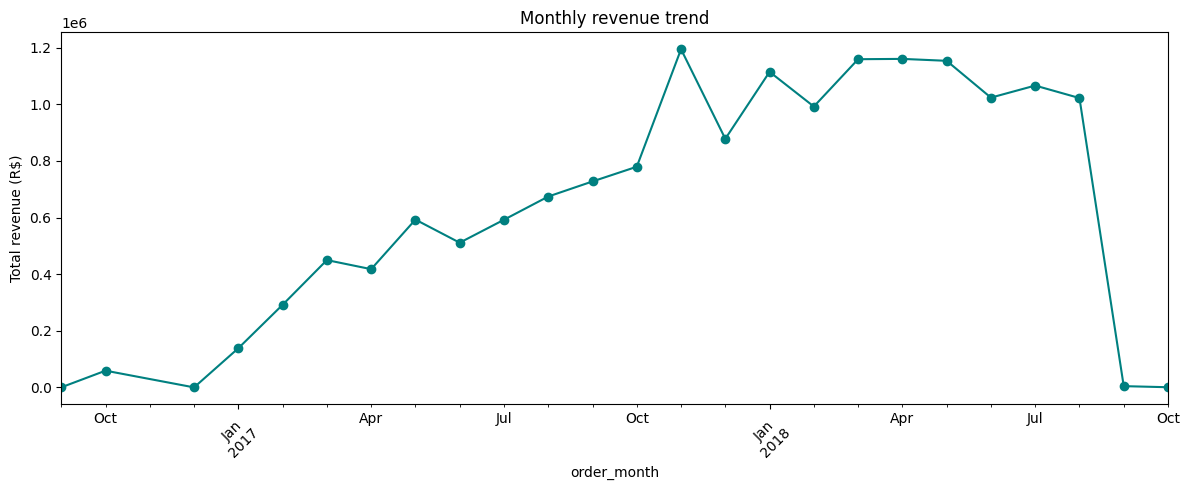

In [22]:
monthly_revenue = (df.groupby('order_month')['total_payment']
                     .sum())

plt.figure(figsize=(12, 5))
monthly_revenue.plot(kind='line', color='teal', marker='o')
plt.title('Monthly revenue trend')
plt.ylabel('Total revenue (R$)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('monthly_revenue.png')
plt.show()

In [23]:
import os

export_path = "C:/Users/prava/Downloads/ecommerce sales/powerbi_export/"
os.makedirs(export_path, exist_ok=True)

df_export = df[['order_id','customer_id','order_status',
    'order_purchase_timestamp','order_delivered_customer_date',
    'order_estimated_delivery_date','delivery_days','delivery_delay',
    'order_month','order_dayofweek','review_score','total_payment',
    'payment_type','customer_state','product_category_name_english']].copy()
df_export['is_late'] = (df_export['delivery_delay'] > 0).astype(int)
for col in ['order_purchase_timestamp','order_delivered_customer_date','order_estimated_delivery_date']:
    df_export[col] = pd.to_datetime(df_export[col]).dt.strftime('%Y-%m-%d')
df_export.to_csv(export_path + "fact_orders.csv", index=False)
print(f"fact_orders.csv → {len(df_export):,} rows")

rfm[['customer_id','Recency','Frequency','Monetary','R_score','F_score','M_score','RFM_score','Segment']].to_csv(export_path + "dim_customers_rfm.csv", index=False)
print(f"dim_customers_rfm.csv → {len(rfm):,} rows")

monthly = df.groupby('order_month').agg(total_orders=('order_id','count'),total_revenue=('total_payment','sum'),avg_review=('review_score','mean'),late_orders=('delivery_delay',lambda x:(x>0).sum())).reset_index()
monthly['order_month'] = monthly['order_month'].astype(str)
monthly['late_pct'] = (monthly['late_orders']/monthly['total_orders']*100).round(2)
monthly.to_csv(export_path + "agg_monthly.csv", index=False)
print(f"agg_monthly.csv → {len(monthly):,} rows")

cat = df.groupby('product_category_name_english').agg(total_revenue=('total_payment','sum'),total_orders=('order_id','count'),avg_review=('review_score','mean')).reset_index().sort_values('total_revenue',ascending=False).head(20)
cat.to_csv(export_path + "agg_category.csv", index=False)
print(f"agg_category.csv → {len(cat):,} rows")

state = df.groupby('customer_state').agg(total_orders=('order_id','count'),total_revenue=('total_payment','sum'),avg_review=('review_score','mean'),avg_delivery=('delivery_days','mean'),late_orders=('delivery_delay',lambda x:(x>0).sum())).reset_index()
state['late_pct'] = (state['late_orders']/state['total_orders']*100).round(2)
state.to_csv(export_path + "agg_state.csv", index=False)
print(f"agg_state.csv → {len(state):,} rows")

pay = df.groupby('payment_type').agg(total_orders=('order_id','count'),total_revenue=('total_payment','sum'),avg_value=('total_payment','mean')).reset_index()
pay.to_csv(export_path + "agg_payment.csv", index=False)
print(f"agg_payment.csv → {len(pay):,} rows")

print("\n✅ All 6 files exported to:", export_path)

fact_orders.csv → 99,441 rows
dim_customers_rfm.csv → 99,441 rows
agg_monthly.csv → 25 rows
agg_category.csv → 20 rows
agg_state.csv → 27 rows
agg_payment.csv → 5 rows

✅ All 6 files exported to: C:/Users/prava/Downloads/ecommerce sales/powerbi_export/


In [25]:
import sqlite3
import pandas as pd
 
conn = sqlite3.connect(':memory:')

In [26]:
path = "C:/Users/prava/Downloads/ecommerce sales/"
 
orders_raw      = pd.read_csv(path + "olist_orders_dataset.csv")
customers_raw   = pd.read_csv(path + "olist_customers_dataset.csv")
items_raw       = pd.read_csv(path + "olist_order_items_dataset.csv")
payments_raw    = pd.read_csv(path + "olist_order_payments_dataset.csv")
reviews_raw     = pd.read_csv(path + "olist_order_reviews_dataset.csv")
sellers_raw     = pd.read_csv(path + "olist_sellers_dataset.csv")
products_raw    = pd.read_csv(path + "olist_products_dataset.csv")
translation_raw = pd.read_csv(path + "product_category_name_translation.csv")

In [28]:
orders_raw.to_sql('orders',               conn, index=False, if_exists='replace')
customers_raw.to_sql('customers',         conn, index=False, if_exists='replace')
items_raw.to_sql('order_items',           conn, index=False, if_exists='replace')
payments_raw.to_sql('payments',           conn, index=False, if_exists='replace')
reviews_raw.to_sql('reviews',             conn, index=False, if_exists='replace')
sellers_raw.to_sql('sellers',             conn, index=False, if_exists='replace')
products_raw.to_sql('products',           conn, index=False, if_exists='replace')
translation_raw.to_sql('category_translation', conn, index=False, if_exists='replace')

71

In [29]:
def sql(query):
    return pd.read_sql_query(query, conn)
 
print("All tables loaded into SQLite!")
 



All tables loaded into SQLite!


In [31]:
sql("""
SELECT o.order_status,
       COUNT(DISTINCT o.order_id)     AS total_orders,
       ROUND(SUM(p.payment_value),2)  AS total_revenue,
       ROUND(AVG(p.payment_value),2)  AS avg_order_value
FROM orders o
LEFT JOIN payments p ON o.order_id = p.order_id
GROUP BY o.order_status
ORDER BY total_orders DESC
""")


,order_status,total_orders,total_revenue,avg_order_value
0,delivered,96478,15422461.77,153.07
1,shipped,1107,177213.96,151.98
2,canceled,625,143255.60,215.75
3,unavailable,609,126479.51,194.88
4,invoiced,314,69137.99,212.73
5,processing,301,69394.11,217.54
6,created,5,688.10,137.62
7,approved,2,241.08,120.54


In [32]:
q2 = sql("""
SELECT STRFTIME('%Y-%m', order_purchase_timestamp) AS month,
       COUNT(DISTINCT o.order_id)                  AS orders,
       ROUND(SUM(p.payment_value),2)               AS revenue
FROM orders o
LEFT JOIN payments p ON o.order_id = p.order_id
WHERE o.order_status = 'delivered'
GROUP BY month ORDER BY month
""")
print(q2.tail())

      month  orders     revenue
18  2018-04    6798  1132933.95
19  2018-05    6749  1128836.69
20  2018-06    6099  1012090.68
21  2018-07    6159  1027903.86
22  2018-08    6351   985414.28


In [33]:
q3 = sql("""
SELECT COALESCE(t.product_category_name_english,
               p.product_category_name,'Unknown') AS category,
       COUNT(DISTINCT oi.order_id) AS orders,
       ROUND(SUM(oi.price),2)      AS revenue,
       ROUND(AVG(oi.price),2)      AS avg_price
FROM order_items oi
LEFT JOIN products p             ON oi.product_id = p.product_id
LEFT JOIN category_translation t ON p.product_category_name
                                  = t.product_category_name
GROUP BY category
ORDER BY revenue DESC LIMIT 10
""")
print(q3)

                category  orders     revenue  avg_price
0          health_beauty    8836  1258681.34     130.16
1          watches_gifts    5624  1205005.68     201.14
2         bed_bath_table    9417  1036988.68      93.30
3         sports_leisure    7720   988048.97     114.34
4  computers_accessories    6689   911954.32     116.51
5        furniture_decor    6449   729762.49      87.56
6             cool_stuff    3632   635290.85     167.36
7             housewares    5884   632248.66      90.79
8                   auto    3897   592720.11     139.96
9           garden_tools    3518   485256.46     111.63


In [34]:
q4 = sql("""
SELECT
  CASE
    WHEN JULIANDAY(order_delivered_customer_date) -
         JULIANDAY(order_estimated_delivery_date) < -3
         THEN 'Very early'
    WHEN JULIANDAY(order_delivered_customer_date) -
         JULIANDAY(order_estimated_delivery_date) < 0
         THEN 'On time'
    WHEN JULIANDAY(order_delivered_customer_date) -
         JULIANDAY(order_estimated_delivery_date) <= 3
         THEN 'Slightly late'
    ELSE 'Very late'
  END                           AS delivery_bucket,
  COUNT(DISTINCT o.order_id)    AS orders,
  ROUND(AVG(r.review_score),2)  AS avg_score
FROM orders o
LEFT JOIN reviews r ON o.order_id = r.order_id
WHERE o.order_delivered_customer_date IS NOT NULL
GROUP BY delivery_bucket
ORDER BY avg_score DESC
""")
print(q4)


  delivery_bucket  orders  avg_score
0      Very early   83906       4.30
1         On time    4743       4.13
2   Slightly late    2662       3.77
3       Very late    5165       1.94


In [35]:
q5 = sql("""
SELECT c.customer_state,
       COUNT(DISTINCT o.order_id)    AS orders,
       ROUND(AVG(
         JULIANDAY(order_delivered_customer_date) -
         JULIANDAY(order_purchase_timestamp)),1) AS avg_days,
       ROUND(AVG(r.review_score),2)  AS avg_score
FROM orders o
LEFT JOIN customers c ON o.customer_id = c.customer_id
LEFT JOIN reviews   r ON o.order_id    = r.order_id
WHERE o.order_delivered_customer_date IS NOT NULL
GROUP BY c.customer_state
ORDER BY orders DESC LIMIT 10
""")
print(q5)

  customer_state  orders  avg_days  avg_score
0             SP   40495       8.8       4.25
1             RJ   12353      15.3       3.96
2             MG   11355      12.0       4.19
3             RS    5344      15.3       4.19
4             PR    4923      12.0       4.24
5             SC    3547      15.0       4.13
6             BA    3256      19.4       3.93
7             DF    2080      13.0       4.13
8             ES    1995      15.8       4.08
9             GO    1957      15.6       4.10


In [36]:
q6 = sql("""
SELECT payment_type,
       COUNT(DISTINCT order_id)            AS orders,
       ROUND(SUM(payment_value),2)         AS revenue,
       ROUND(AVG(payment_value),2)         AS avg_payment,
       ROUND(AVG(payment_installments),1)  AS avg_install
FROM payments
GROUP BY payment_type
ORDER BY orders DESC
""")
print(q6)

  payment_type  orders      revenue  avg_payment  avg_install
0  credit_card   76505  12542084.19       163.32          3.5
1       boleto   19784   2869361.27       145.03          1.0
2      voucher    3866    379436.87        65.70          1.0
3   debit_card    1528    217989.79       142.57          1.0
4  not_defined       3         0.00         0.00          1.0


In [37]:
q7 = sql("""
SELECT oi.seller_id, s.seller_state,
       COUNT(DISTINCT oi.order_id)   AS orders,
       ROUND(SUM(oi.price),2)        AS revenue,
       ROUND(AVG(r.review_score),2)  AS avg_rating
FROM order_items oi
LEFT JOIN sellers s ON oi.seller_id = s.seller_id
LEFT JOIN reviews r ON oi.order_id  = r.order_id
GROUP BY oi.seller_id
ORDER BY revenue DESC LIMIT 10
""")
print(q7)

                          seller_id seller_state  orders    revenue  \
0  4869f7a5dfa277a7dca6462dcf3b52b2           SP    1132  229472.63   
1  53243585a1d6dc2643021fd1853d8905           BA     358  222776.05   
2  4a3ca9315b744ce9f8e9374361493884           SP    1806  202999.12   
3  fa1c13f2614d7b5c4749cbc52fecda94           SP     585  194042.03   
4  7c67e1448b00f6e969d365cea6b010ab           SP     982  189417.67   
5  7e93a43ef30c4f03f38b393420bc753a           SP     336  176431.87   
6  da8622b14eb17ae2831f4ac5b9dab84a           SP    1314  162723.37   
7  7a67c85e85bb2ce8582c35f2203ad736           SP    1160  142325.49   
8  1025f0e2d44d7041d6cf58b6550e0bfa           SP     915  140513.14   
9  955fee9216a65b617aa5c0531780ce60           SP    1287  135241.70   

   avg_rating  
0        4.12  
1        4.08  
2        3.80  
3        4.34  
4        3.35  
5        4.21  
6        4.07  
7        4.23  
8        3.85  
9        4.05  


In [38]:
q8 = sql("""
WITH base AS (
  SELECT c.customer_unique_id,
    CAST(JULIANDAY('now') -
         JULIANDAY(MAX(o.order_purchase_timestamp)) AS INT) AS recency,
    COUNT(DISTINCT o.order_id)     AS frequency,
    ROUND(SUM(p.payment_value),2)  AS monetary
  FROM orders o
  LEFT JOIN customers c ON o.customer_id = c.customer_id
  LEFT JOIN payments  p ON o.order_id    = p.order_id
  WHERE o.order_status = 'delivered'
  GROUP BY c.customer_unique_id
),
seg AS (
  SELECT *,
    CASE
      WHEN recency<=90  AND frequency>=3 THEN 'Champions'
      WHEN recency<=90                   THEN 'Recent'
      WHEN frequency>=3                  THEN 'Loyal'
      WHEN recency>=365                  THEN 'Lost'
      ELSE                                    'At risk'
    END AS segment
  FROM base
)
SELECT segment,
  COUNT(*)                AS customers,
  ROUND(AVG(recency),1)   AS avg_recency,
  ROUND(AVG(frequency),2) AS avg_freq,
  ROUND(AVG(monetary),2)  AS avg_spend
FROM seg GROUP BY segment ORDER BY customers DESC
""")
print(q8)


  segment  customers  avg_recency  avg_freq  avg_spend
0    Lost      93130       3050.6      1.03     164.36
1   Loyal        228       3014.9      3.40     506.79


In [39]:
q9 = sql("""
SELECT oi.seller_id,
  COUNT(DISTINCT oi.order_id) AS orders,
  SUM(CASE WHEN JULIANDAY(order_delivered_customer_date) >
                JULIANDAY(order_estimated_delivery_date)
           THEN 1 ELSE 0 END) AS late,
  ROUND(100.0 * SUM(CASE WHEN JULIANDAY(order_delivered_customer_date) >
                              JULIANDAY(order_estimated_delivery_date)
                         THEN 1 ELSE 0 END)
        / COUNT(DISTINCT oi.order_id), 1) AS late_pct
FROM order_items oi
LEFT JOIN orders o ON oi.order_id = o.order_id
WHERE order_delivered_customer_date IS NOT NULL
  AND order_estimated_delivery_date IS NOT NULL
GROUP BY oi.seller_id
HAVING orders >= 20
ORDER BY late_pct DESC LIMIT 10
""")
print(q9)

                          seller_id  orders  late  late_pct
0  2709af9587499e95e803a6498a5a56e9      25    23      92.0
1  f76a3b1349b6df1ee875d1f3fa4340f0      24     9      37.5
2  821fb029fc6e495ca4f08a35d51e53a5      24     9      37.5
3  ede0c03645598cdfc63ca8237acbe73d      43    16      37.2
4  835f0f7810c76831d6c7d24c7a646d4d      42    15      35.7
5  54965bbe3e4f07ae045b90b0b8541f52      73    26      35.6
6  2a261b5b644fa05f4f2700eb93544f2c      51    18      35.3
7  99a54764c341d5dc80b4a8fac4eba3fb      44    15      34.1
8  4e5725ba188db8252977a4f0227bd462      21     7      33.3
9  ad781527c93d00d89a11eecd9dcad7c1      38    12      31.6


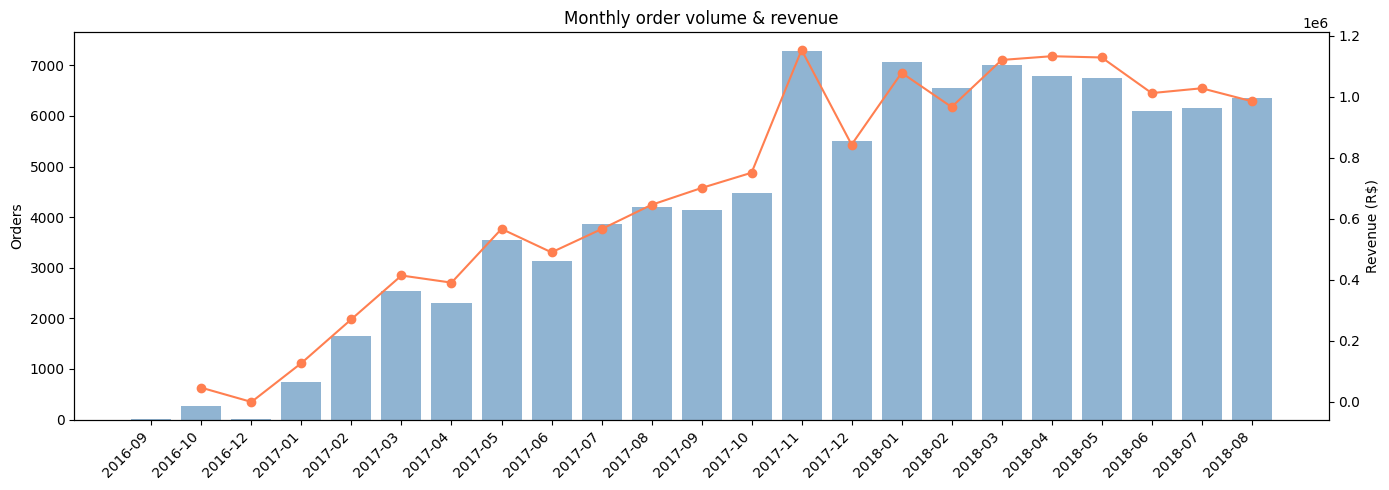

In [40]:
fig, ax1 = plt.subplots(figsize=(14,5))
ax2 = ax1.twinx()
ax1.bar(q2['month'], q2['orders'], color='steelblue', alpha=0.6, label='Orders')
ax2.plot(q2['month'], q2['revenue'], color='coral', marker='o', label='Revenue')
ax1.set_xticklabels(q2['month'], rotation=45, ha='right')
ax1.set_ylabel('Orders'); ax2.set_ylabel('Revenue (R$)')
plt.title('Monthly order volume & revenue')
plt.tight_layout(); plt.savefig('sql_monthly.png'); plt.show()